## UMAP visualization to explore data


📂 Processing Split: TEST

🔹 Analyzing Combination: G+H+F
   💾 Saved to umap_test_g_h_f.png


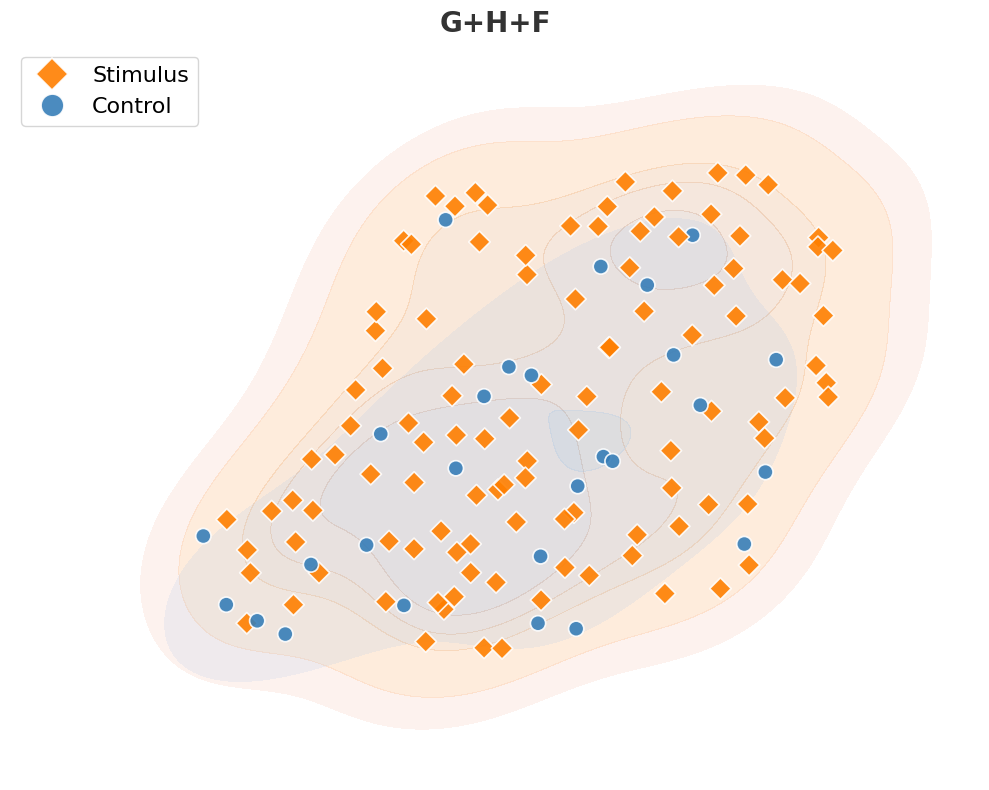


✅ Analysis complete!


In [6]:
# %% [markdown]
# # 🗺️ Aesthetic Multimodal UMAP Analysis
# **Goal:** Visualize infant movement manifolds with high-contrast, colorblind-safe, publication-quality plots.

# %%
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from itertools import combinations
import umap

# suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# --- Project Root Setup ---
def find_project_root(name='Bambino', start=None):
    if start is None: start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name: return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir: return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
if PROJECT_ROOT: sys.path.append(PROJECT_ROOT)

from config import settings
from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset

# %% --- Configuration ---
DATASET_TYPE = "preprocessed"  # 'normalized' or 'augmented_normalized'
TARGET_LEN = 250             # Flattening length
RANDOM_STATE = 42            # Reproducibility

# Splits
SPLITS_TO_RUN = ["test"] 

OUTPUT_DIR = Path(f"./umap_plots_{DATASET_TYPE}_fancy")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODALITIES_MAP = {
    'g': 'gaze_info',
    'h': 'head_info',
    'f': 'face_info'
}

ALL_COMBINATIONS = False  # If False, only runs the specified combination (e.g., all modalities together)

# --- 🎨 Visual Styling ---
# 1. Colorblind Safe Palette (Blue vs Orange)
# CRITICAL FIX: Keys must match the string labels used in the dataframe
CB_PALETTE = {'Control': "#377eb8", 'Stimulus': "#ff7f00"} 
LABELS = {0: 'Control', 1: 'Stimulus'}

# %% --- Helpers ---

def extract_flat_features(ds, active_modalities, target_len=TARGET_LEN):
    """
    Extracts and flattens time-series data.
    """
    X_list = []
    y_list = []
    
    active_attrs = [MODALITIES_MAP[k] for k in active_modalities]

    for inst in ds.instances:
        mats = []
        for attr in active_attrs:
            mat = np.asarray(getattr(inst, attr))
            mats.append(mat)
        
        # Concatenate channels -> [Length, Channels]
        X = np.concatenate(mats, axis=1)
        
        # Pad/Truncate
        L = X.shape[0]
        if L >= target_len:
            start = (L - target_len) // 2
            X_t = X[start:start+target_len, :]
        else:
            pad = np.zeros((target_len - L, X.shape[1]), dtype=X.dtype)
            X_t = np.vstack([X, pad])
            
        # Flatten -> [Length * Channels]
        X_flat = X_t.flatten()
        
        X_list.append(X_flat)
        y_list.append(int(inst.trial_type))

    return np.array(X_list), np.array(y_list)

def compute_and_plot_umap(X, y, title, save_path=None):
    """
    Runs UMAP and creates a colorblind-friendly plot with density contours.
    """
    
    # 1. Compute UMAP
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=RANDOM_STATE)
    embedding = reducer.fit_transform(X)
    
    # 2. Prepare Data
    df_umap = pd.DataFrame(embedding, columns=['x', 'y'])
    df_umap['label'] = y
    df_umap['Class'] = df_umap['label'].map(LABELS)
    
    # 3. Plotting
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # --- A. Density Contours (The "Fancy" Part) ---
    try:
        sns.kdeplot(
            data=df_umap, x='x', y='y', hue='Class',
            palette=CB_PALETTE, fill=True, alpha=0.15, 
            levels=6, thresh=0.1, legend=False, ax=ax,
            cut=2 # Extends the contours slightly past the data
        )
    except Exception as e:
        # Fallback if KDE fails (e.g., too few points or singular matrix)
        print(f"   ⚠️ KDE Plot failed ({e}), skipping contours.")
    
    # --- B. Scatter Points ---
    sns.scatterplot(
        data=df_umap, x='x', y='y', hue='Class',
        palette=CB_PALETTE,
        style='Class',          
        markers={'Control': 'o', 'Stimulus': 'D'}, 
        s=120,                  
        alpha=0.9,
        edgecolor='white',      
        linewidth=1.2,
        ax=ax,
        legend=True # Ensure legend is generated here
    )
    
    # --- C. Clean Up (No Axes) ---
    ax.axis('off')
    
    # Add a minimal legend manually to ensure it looks good
    # We grab handles from the scatterplot
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles, labels=labels,
        title=None, 
        loc='upper left', 
        frameon=True, 
        fontsize=16,
        markerscale=1.5
    )

    # Title styling
    plt.title(title, fontsize=20, fontweight='bold', color='#333333', pad=10)
    
    # 4. Save & Show
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False)
        print(f"   💾 Saved to {save_path.name}")
        
    plt.show()

# %% --- Main Execution Loop ---

for split_name in SPLITS_TO_RUN:
    print(f"\n{'='*60}")
    print(f"📂 Processing Split: {split_name.upper()}")
    print(f"{'='*60}")

    # Load Dataset
    filename = getattr(settings, f"{split_name}_filename")
    path = settings.get_dataset_path(DATASET_TYPE, filename)
    
    try:
        dataset = BoaOpenFaceDataset.load_dataset(path)
    except FileNotFoundError:
        print(f"⚠️ Dataset not found for {split_name} at {path}. Skipping.")
        continue
    
    # Modality Combinations
    keys = list(MODALITIES_MAP.keys())

    if ALL_COMBINATIONS:
        # Iterate through all combinations (Size 1 to 3)
        for r in range(1, len(keys) + 1):
            for combo in combinations(keys, r):
                
                combo_str = "+".join([k.upper() for k in combo])
                print(f"\n🔹 Analyzing Combination: {combo_str}")
                
                # Extract
                X, y = extract_flat_features(dataset, active_modalities=combo)
                
                # Skip if empty
                if len(X) == 0:
                    print("   ⚠️ No data found.")
                    continue

                # Plot
                filename = f"umap_{split_name}_{'_'.join(combo)}.png"
                title = f"{combo_str}"
                
                compute_and_plot_umap(X, y, title=title, save_path=OUTPUT_DIR / filename)

    else:
        # Only run the specified combination (e.g., all modalities)
        combo = keys  # Use all modalities
        combo_str = "+".join([k.upper() for k in combo])
        print(f"\n🔹 Analyzing Combination: {combo_str}")

        # Extract
        X, y = extract_flat_features(dataset, active_modalities=combo)

        # Skip if empty
        if len(X) == 0:
            print("   ⚠️ No data found.")
            continue

        # Plot
        filename = f"umap_{split_name}_{'_'.join(combo)}.png"
        title = f"{combo_str}"
        
        compute_and_plot_umap(X, y, title=title, save_path=OUTPUT_DIR / filename)

print("\n✅ Analysis complete!")



🌍 RUNNING COMBINED UMAP (All Splits)

📂 Processing Type: RAW
   ✅ Loaded training (619 samples)
   ✅ Loaded validation (140 samples)
   ✅ Loaded test (137 samples)
   💾 Saved to umap_raw.png


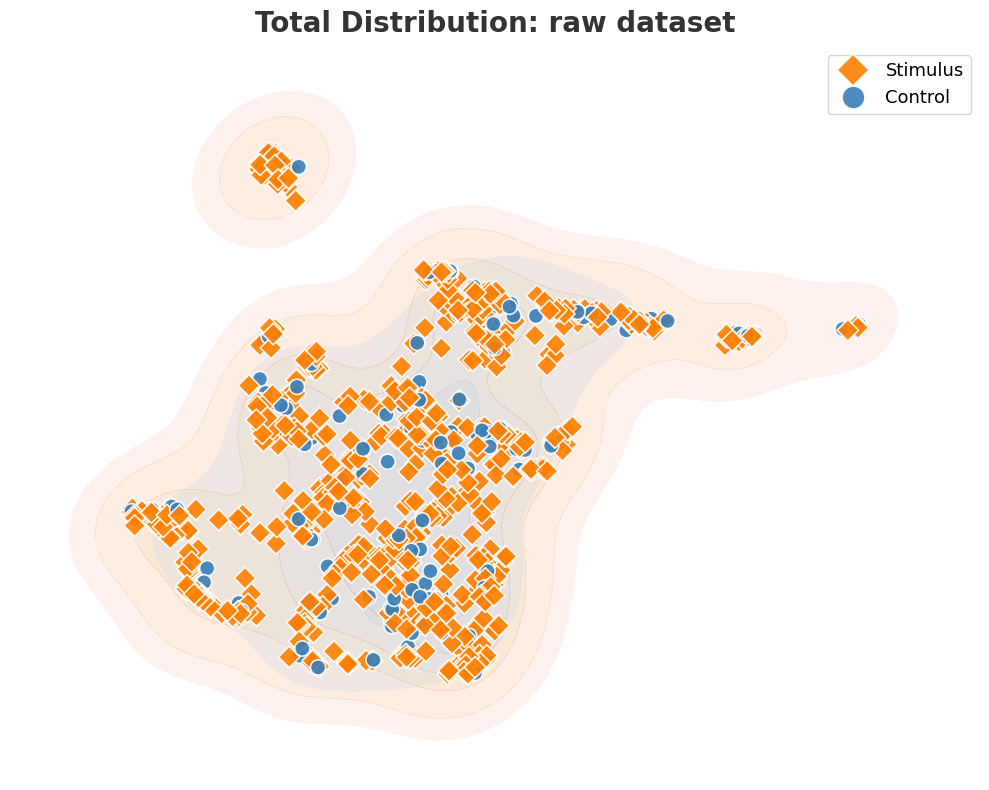


📂 Processing Type: PREPROCESSED
   ✅ Loaded training (619 samples)
   ✅ Loaded validation (140 samples)
   ✅ Loaded test (137 samples)
   💾 Saved to umap_preprocessed.png


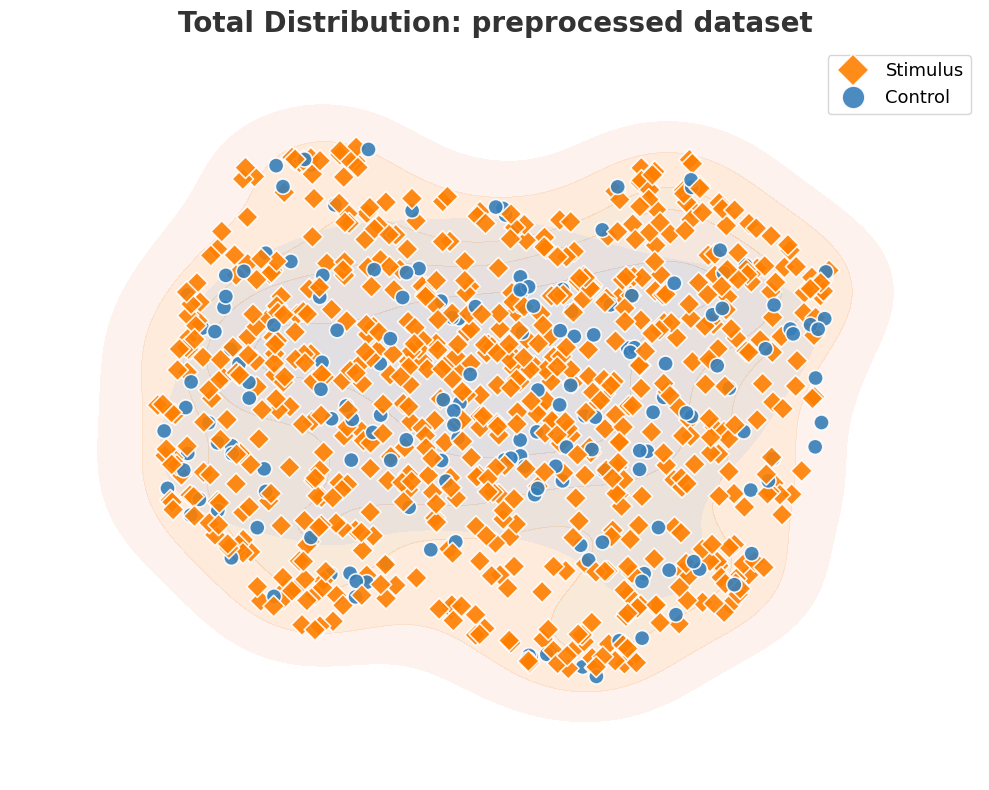


📂 Processing Type: NORMALIZED
   ✅ Loaded training (619 samples)
   ✅ Loaded validation (140 samples)
   ✅ Loaded test (137 samples)
   💾 Saved to umap_normalized.png


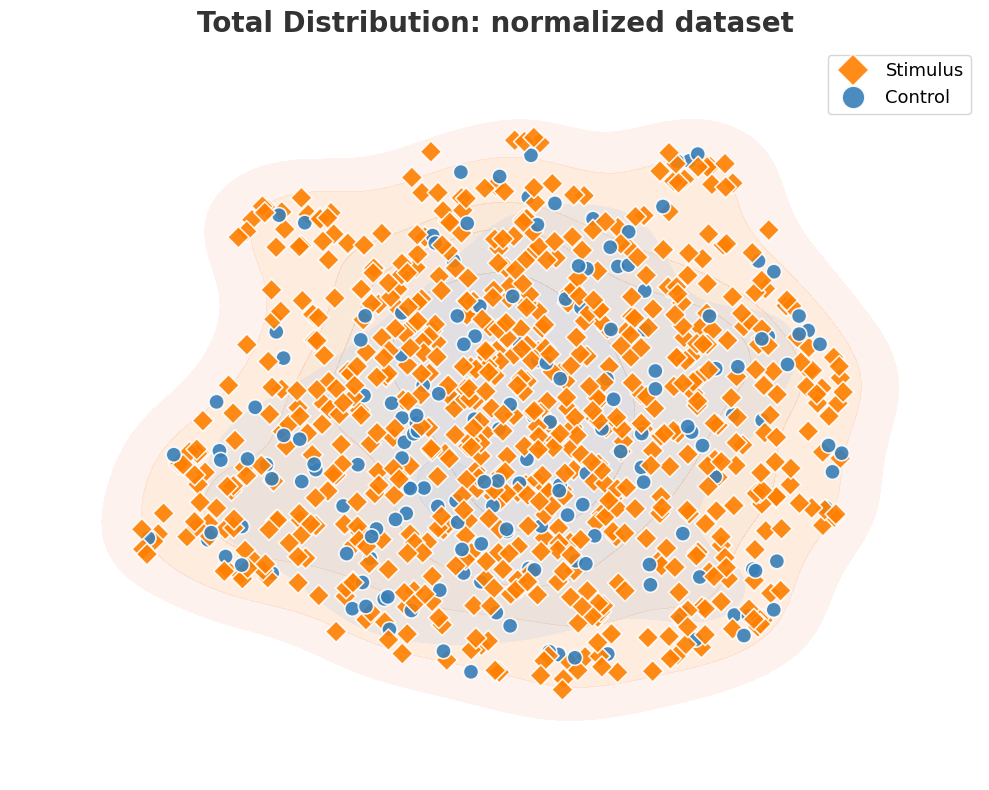


📂 Processing Type: AUGMENTED
   ✅ Loaded training (1970 samples)
   ✅ Loaded validation (140 samples)
   ✅ Loaded test (137 samples)
   💾 Saved to umap_augmented.png


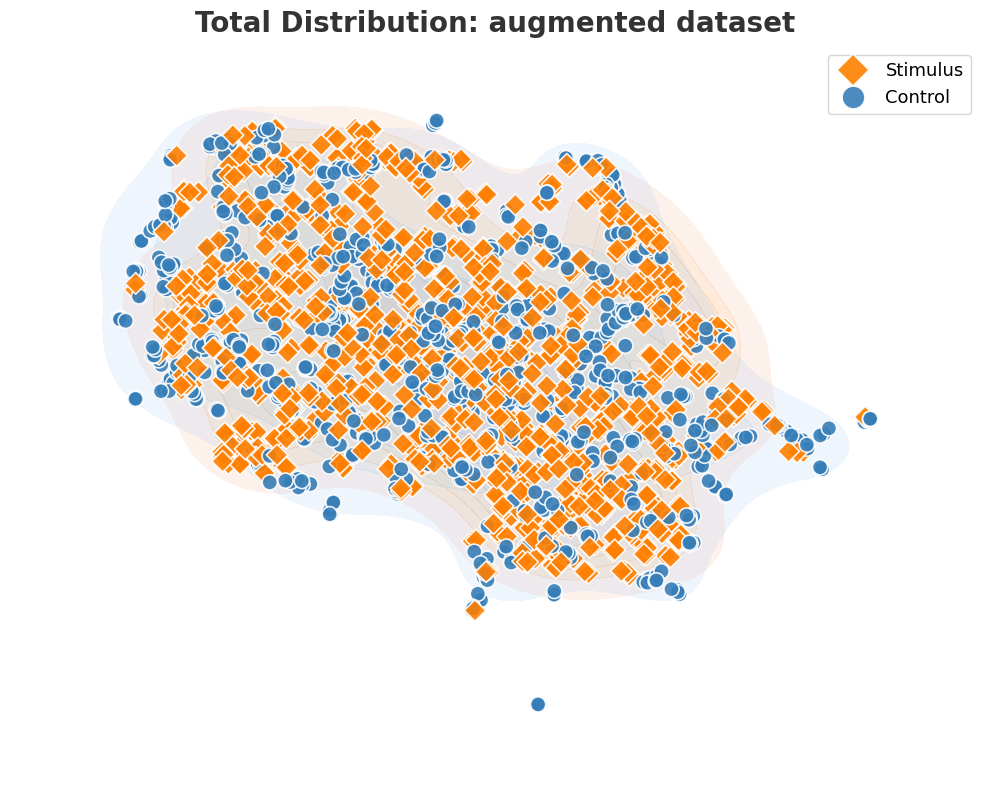


📂 Processing Type: AUGMENTED_NORMALIZED
   ✅ Loaded training (1970 samples)
   ✅ Loaded validation (140 samples)
   ✅ Loaded test (137 samples)
   💾 Saved to umap_augmented_normalized.png


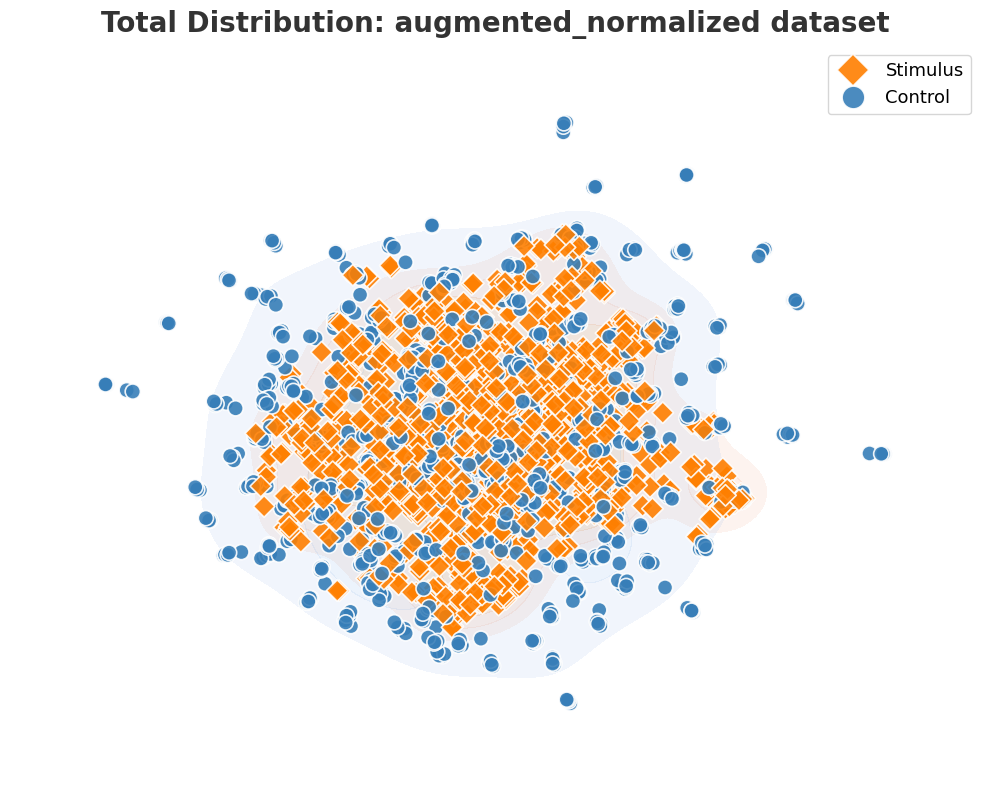

In [5]:
# %% --- Combined UMAP Analysis ---
print(f"\n{'='*60}")
print("🌍 RUNNING COMBINED UMAP (All Splits)")
print(f"{'='*60}")

# Configuration for this block
ALL_SPLITS = ["training", "validation", "test"] 

DATASET_TYPES = ["raw", "preprocessed", "normalized", "augmented", "augmented_normalized"]

# Create a temporary class to mimic the dataset structure expected by extract_flat_features
class TempDataset:
    def __init__(self, instances):
        self.instances = instances

# Loop through each dataset type independently
for dataset_type in DATASET_TYPES:
    
    print(f"\n📂 Processing Type: {dataset_type.upper()}")
    
    # CRITICAL FIX: Reset the list for each dataset_type!
    combined_instances = [] 
    
    for split_name in ALL_SPLITS:
        # Handle naming difference if necessary (train vs training)
        attr_name = f"{split_name}_filename"
        
        if not hasattr(settings, attr_name):
            print(f"   ⚠️ Settings missing '{attr_name}'. Skipping.")
            continue
            
        filename = getattr(settings, attr_name)
        
        # Construct path manually or via helper
        # Note: Ensure get_dataset_path handles the list of types correctly if it expects a string
        try:
            path = settings.get_dataset_path(dataset_type, filename)
            
            if os.path.exists(path):
                ds = BoaOpenFaceDataset.load_dataset(path)
                combined_instances.extend(ds.instances)
                print(f"   ✅ Loaded {split_name} ({len(ds.instances)} samples)")
            else:
                print(f"   ⚠️ File not found: {path}")
                
        except Exception as e:
            print(f"   ❌ Error loading {split_name}: {e}")

    # If we have data, plot it
    if len(combined_instances) > 0:
        
        # Wrap in temp object
        combined_ds = TempDataset(combined_instances)

        # Use ALL modalities for this comprehensive view
        keys = list(MODALITIES_MAP.keys()) # ['g', 'h', 'f']
        
        # Extract features
        X, y = extract_flat_features(combined_ds, active_modalities=keys)

        if len(X) > 0:
            # Output setup
            combo_str = "+".join([k.upper() for k in keys])
            filename = f"umap_{dataset_type}.png"
            title = f"Total Distribution: {dataset_type} dataset"
            
            # Use your existing plotting function
            compute_and_plot_umap(X, y, title=title, save_path=OUTPUT_DIR / filename)
        else:
            print("   ⚠️ Feature extraction resulted in empty array.")
    else:
        print(f"   ⚠️ No instances found for dataset type: {dataset_type}")